In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from os import path, makedirs
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')
from pyanalib.split_df_helpers import load_dfs
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
plt.style.use("presentation.mplstyle")

In [ ]:
# --- paths ---
import os
import glob as glob_module
import gc
import pickle

DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"
DIR_DATA = path.join(DFS_ROOT, "2026_05_16_230759__sel_2prong-data-1e20")
# QUALITY_DF_PATH = path.join(QUALITY_DF_DIR, "beam_data_1e20_qualitycut.df")

DIR_MC = path.join(DFS_ROOT, "2026_05_06_073032__sel_2prong-mc-BNB_cosmics")
DIR_INTIME = path.join(DFS_ROOT, "2026_05_05_193232__sel_2prong-mc-Intime")
DIR_OFFBEAM = path.join(DFS_ROOT, "2026_05_05_233424__sel_2prong-data-OffBeamLight")
DIR_DIRT = path.join(DFS_ROOT, "2026_05_06_135816__sel_2prong-mc-dirt")

KEYS2LOAD = ["hdr", "evt"]
N_MAX_CONCAT = 999

FOM_CUT = 0.98
MIN_RUN_DURATION_MIN = 20.0

save_fig = True
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(
    save_fig_base_dir,
    f"data_mc_chi2_comparison_{today_str}",
)
if save_fig and not path.exists(save_fig_dir):
    makedirs(save_fig_dir)
makedirs(WIREMOD_CACHE_DIR, exist_ok=True)
# print("quality-cut df:", QUALITY_DF_PATH)
print("saving plots in", save_fig_dir)
print("WireMod sel_mup matched files:", {k: len(v) for k, v in VARIATIONS_MUP.items()})
print("WireMod hist cache:", CACHE_PATH_MUP)

saving plots in /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602
WireMod sel_mup matched files: {'YZ': 47, 'XTXW': 47, 'CV': 46}
WireMod hist cache: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/wiremod_matched_hists_sel_mup_homog.pkl


In [5]:
from pyanalib.split_df_helpers_new import dfs_from_dir

mc_dfs = dfs_from_dir(
    DIR_MC,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
intime_dfs = dfs_from_dir(
    DIR_INTIME,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
offbeam_dfs = dfs_from_dir(
    DIR_OFFBEAM,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
dirt_dfs = dfs_from_dir(
    DIR_DIRT,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
data_dfs = dfs_from_dir(
    DIR_DATA,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)

mc_evt_df = mc_dfs["evt"]
mc_hdr_df = mc_dfs["hdr"]

intime_evt_df = intime_dfs["evt"]
intime_hdr_df = intime_dfs["hdr"]

offbeam_evt_df = offbeam_dfs["evt"]
offbeam_hdr_df = offbeam_dfs["hdr"]

dirt_evt_df = dirt_dfs["evt"]
dirt_hdr_df = dirt_dfs["hdr"]

data_evt_df = data_dfs["evt"]
data_hdr_df = data_dfs["hdr"]

print(f"mc:      evt={len(mc_evt_df):,}  hdr={len(mc_hdr_df):,}")
print(f"intime:  evt={len(intime_evt_df):,}  hdr={len(intime_hdr_df):,}")
print(f"offbeam: evt={len(offbeam_evt_df):,}  hdr={len(offbeam_hdr_df):,}")
print(f"dirt:    evt={len(dirt_evt_df):,}  hdr={len(dirt_hdr_df):,}")
print(f"data:    evt={len(data_evt_df):,}  hdr={len(data_hdr_df):,}")

mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
dirt_evt_df.loc[dirt_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999

data_evt_df[("mc", "iscc")] = 999
print(f"evt_good rows: {len(data_evt_df):,}")

Found 999 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1002.df', '/pnfs/sbnd/scratch/users/munjung/cafpy

100%|██████████| 999/999 [09:43<00:00,  1.71it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 200 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232_

100%|██████████| 200/200 [01:55<00:00,  1.74it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 200 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamL

...

100%|██████████| 500/500 [03:24<00:00,  2.45it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 100 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_11.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_12.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_13.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_14.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel

100%|██████████| 100/100 [01:17<00:00,  1.30it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
mc:      evt=725,456  hdr=3,187,761
intime:  evt=159,230  hdr=2,149,555
offbeam: evt=170,151  hdr=1,655,098
dirt:    evt=110,336  hdr=1,631,640
data:    evt=342,761  hdr=1,773,921
evt_good rows: 342,761


/tmp/ipykernel_1853943/3331057512.py:55: PerformanceWarning: indexing past lexsort depth may impact performance.
  mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
/tmp/ipykernel_1853943/3331057512.py:56: PerformanceWarning: indexing past lexsort depth may impact performance.
  dirt_evt_df.loc[dirt_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
/tmp/ipykernel_1853943/3331057512.py:58: PerformanceWarning: indexing past lexsort depth may impact performance.
  data_evt_df[("mc", "iscc")] = 999


In [6]:
data_tot_pot = data_hdr_df["pot"].sum()
data_gates = data_hdr_df.nbnbinfo.sum()


pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

data_evt_df["pot_weight"] = np.ones(len(data_evt_df))

mc_tot_pot = mc_hdr_df["pot"].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot
print(f"mc_pot_scale: {mc_pot_scale:.3e}")
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))

dirt_tot_pot = dirt_hdr_df["pot"].sum()
dirt_pot_scale = data_tot_pot / dirt_tot_pot
print(f"dirt_pot_scale: {dirt_pot_scale:.3e}")
dirt_evt_df["pot_weight"] = dirt_pot_scale * np.ones(len(dirt_evt_df))

intime_gates = offbeam_hdr_df[offbeam_hdr_df["first_in_subrun"] == 1]["noffbeambnb"].sum()
f = 0.08
scale_intime_to_lightdata = (1 - f) * data_gates / intime_gates
print(f"intime data scale: {scale_intime_to_lightdata:.2f}")
intime_evt_df["pot_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))

mc_pot_scale: 3.190e-01
dirt_pot_scale: 2.422e-01
intime data scale: 0.22


/tmp/ipykernel_1853943/3300707135.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_evt_df["pot_weight"] = np.ones(len(data_evt_df))
/tmp/ipykernel_1853943/3300707135.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
/tmp/ipykernel_1853943/3300707135.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

In [58]:
perTPC_inset = 20

def perTPC_cut(df):
    in_TPC1 = (
        InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.trk1.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.trk2.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    )
    in_TPC2 = (
        InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.trk1.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.trk2.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    )
    return in_TPC1 | in_TPC2

mc_evt_df_gen1 = mc_evt_df.loc[perTPC_cut(mc_evt_df)]
data_evt_df_gen1 = data_evt_df.loc[perTPC_cut(data_evt_df)]
intime_evt_df_gen1 = intime_evt_df.loc[perTPC_cut(intime_evt_df)]
dirt_evt_df_gen1 = dirt_evt_df.loc[perTPC_cut(dirt_evt_df)]
offbeam_evt_df_gen1 = offbeam_evt_df.loc[perTPC_cut(offbeam_evt_df)]

print(f"perTPC: data={len(data_evt_df):,} mc={len(mc_evt_df):,} intime={len(intime_evt_df):,} dirt={len(dirt_evt_df):,} offbeam={len(offbeam_evt_df):,}")

perTPC: data=50,145 mc=141,484 intime=12,153 dirt=9,394 offbeam=10,268


In [7]:
for df in (mc_evt_df, data_evt_df, intime_evt_df, dirt_evt_df, offbeam_evt_df):
    df[("trk1", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("trk1", "pfp", "trk", "dir", "x", "", "")],
            df[("trk1", "pfp", "trk", "dir", "y", "", "")],
        )
    )
    df[("trk2", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("trk2", "pfp", "trk", "dir", "x", "", "")],
            df[("trk2", "pfp", "trk", "dir", "y", "", "")],
        )
    )

/tmp/ipykernel_1853943/3365631463.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[("trk1", "pfp", "trk", "phi", "", "", "")] = np.degrees(
/tmp/ipykernel_1853943/3365631463.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[("trk2", "pfp", "trk", "phi", "", "", "")] = np.degrees(
/tmp/ipykernel_1853943/3365631463.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax

In [ ]:
# from pyanalib.variable_calculator import get_cc1p0pi_tki
# from pyanalib.pandas_helpers import pad_column_name

# def evt_df_fixed(df):
#     slc_mudf = df.mu.pfp.trk
#     slc_pdf = df.p.pfp.trk
#     tki_reco = get_cc1p0pi_tki(
#         slc_mudf,
#         slc_pdf,
#         pad_column_name(('P', 'p_muon'), slc_mudf),
#         pad_column_name(('P', 'p_proton'), slc_pdf),
#     )
#     df['del_Tp_x'] = tki_reco['del_Tp_x']
#     df['del_Tp_y'] = tki_reco['del_Tp_y']

#     mc_mudf = df.mu.pfp.trk.truth.p
#     mc_pdf = df.p.pfp.trk.truth.p
#     tki_mc = get_cc1p0pi_tki(
#         mc_mudf,
#         mc_pdf,
#         pad_column_name(('totp',), mc_mudf),
#         pad_column_name(('totp',), mc_pdf),
#     )
#     df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
#     df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
#     df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
#     df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

#     n_before = len(df)
#     df = df[np.abs(df.slc.vertex.x) > 10]
#     if 'topo_categ' not in df.columns:
#         df = df.copy()
#         df.loc[:, 'topo_categ'] = get_topo_category(df)
#     return df, n_before


# mc_evt_df, n_evt_before_fv = evt_df_fixed(mc_evt_df)
# data_evt_df, n_evt_before_fv = evt_df_fixed(data_evt_df)
# intime_evt_df, n_evt_before_fv = evt_df_fixed(intime_evt_df)
# offbeam_evt_df, n_evt_before_fv = evt_df_fixed(offbeam_evt_df)

In [57]:
# Event selection
from analysis_village.numucc_1p0pi.makedf.selections import *

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_contained(df, det=DETECTOR)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)


mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_trackscore(df, TRACKSCORE_TH)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_vtxdist(df, VTXDIST_TH)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

In [9]:
def get_octant_dfs(df):
    """
    Splits a DataFrame into 8 octants based on slc.vertex.x, slc.vertex.y, and slc.vertex.z.
    Dividers are x=0, y=0, z=250.
    Returns a list of 8 DataFrames, one for each octant.
    """
    octants = []
    for i in range(8):
        mask_x = (df.slc.vertex.x >= 0) if ((i >> 2) & 1) else (df.slc.vertex.x < 0)
        mask_y = (df.slc.vertex.y >= 0) if ((i >> 1) & 1) else (df.slc.vertex.y < 0)
        mask_z = (df.slc.vertex.z >= 250) if ((i >> 0) & 1) else (df.slc.vertex.z < 250)
        mask = mask_x & mask_y & mask_z
        octants.append(df[mask])
    return octants

# List of octant titles in matching order
octant_titles = [
    "x<0, y<0, z<250",
    "x<0, y<0, z>=250",
    "x<0, y>=0, z<250",
    "x<0, y>=0, z>=250",
    "x>=0, y<0, z<250",
    "x>=0, y<0, z>=250",
    "x>=0, y>=0, z<250",
    "x>=0, y>=0, z>=250",
]

In [48]:
# ── WireMod: accumulate matched .df histograms + total envelope (wiremod.ipynb) ─
from pyanalib.split_df_helpers import get_n_split
from pyanalib.covariance import cov_from_fraccov, get_covariance_matrix
from analysis_village.numucc_1p0pi.selection_framework import multicol_get_series

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kw: x


def _per_trk_col(evt_df, col_tuple):
    out = []
    top_cols = evt_df.columns.get_level_values(0).unique()
    for trk in ("trk1", "trk2"):
        if trk not in top_cols:
            continue
        try:
            vals = multicol_get_series(evt_df[trk], col_tuple).to_numpy(dtype=float)
            if vals.ndim == 1:
                out.append(vals)
        except Exception:
            pass
    return np.concatenate(out) if out else np.array([], dtype=float)


def _var_def_from_config(vc):
    col = vc.var_evt_reco_col
    return {
        "label": vc.var_labels[0],
        "bins": np.asarray(vc.bins),
        "extract": lambda df, col=col: _per_trk_col(df, col),
    }


HOMOG_WIREMOD_VAR_DEFS = {
    vc.var_save_name: _var_def_from_config(vc)
    for vc in (
        VariableConfig.trk1_chi2_proton(),
        VariableConfig.trk2_chi2_proton(),
        VariableConfig.trk1_direction_phi(),
        VariableConfig.trk2_direction_phi(),
    )
}


def _fill_hists_from_split(df, var_defs, hists):
    if df is None or len(df) == 0:
        return 0
    n = len(df)
    for var_name, cfg in var_defs.items():
        try:
            vals = cfg["extract"](df)
        except Exception:
            continue
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        eps = (cfg["bins"][-1] - cfg["bins"][0]) * 1e-9
        vals = np.clip(vals, cfg["bins"][0], cfg["bins"][-1] - eps)
        counts, _ = np.histogram(vals, bins=cfg["bins"])
        hists[var_name] += counts
    return n


def accumulate_variation(matched_files, universes, var_defs):
    hists = {
        u: {v: np.zeros(len(cfg["bins"]) - 1, dtype=float) for v, cfg in var_defs.items()}
        for u in universes
    }
    n_evts = {u: 0 for u in universes}
    for fpath in tqdm(matched_files):
        try:
            n_split = get_n_split(fpath)
        except Exception as exc:
            print(f"  skip {path.basename(fpath)}: {exc}", flush=True)
            continue
        for i in range(n_split):
            for univ in universes:
                key = f"evt_{univ}_{i}"
                try:
                    df = pd.read_hdf(fpath, key=key)
                except Exception:
                    continue
                n = _fill_hists_from_split(df, var_defs, hists[univ])
                n_evts[univ] += n
                del df
            gc.collect()
    return hists, n_evts


def save_wiremod_hists(cache_path, all_hists, all_nevts, var_defs, variations, universes):
    payload = {
        "version": 1,
        "variations": list(variations.keys()),
        "universes": list(universes),
        "var_defs": {
            name: {"label": cfg["label"], "bins": np.asarray(cfg["bins"])}
            for name, cfg in var_defs.items()
        },
        "hists": {
            vl: {u: {vn: arr.copy() for vn, arr in uh.items()} for u, uh in h.items()}
            for vl, h in all_hists.items()
        },
        "n_evts": all_nevts,
    }
    with open(cache_path, "wb") as fh:
        pickle.dump(payload, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved histogram cache → {cache_path}", flush=True)
    return payload


def load_wiremod_hists(cache_path):
    with open(cache_path, "rb") as fh:
        payload = pickle.load(fh)
    print(
        f"Loaded cache: {len(payload['variations'])} variations, "
        f"{len(payload['universes'])} universes, "
        f"{len(payload['var_defs'])} variables",
        flush=True,
    )
    return payload


def max_envelope_univ_counts(n_cv, hists, var_name, shifted_univs):
    n_cv = np.asarray(n_cv, dtype=float)
    keys = [u for u in shifted_univs if u != "cv" and u in hists]
    if not keys:
        return n_cv.copy()
    stacked = np.stack(
        [np.asarray(hists[u][var_name], dtype=float) for u in keys], axis=0
    )
    lo, hi = stacked.min(axis=0), stacked.max(axis=0)
    diffs_hi, diffs_lo = hi - n_cv, lo - n_cv
    pick_hi = np.abs(diffs_hi) >= np.abs(diffs_lo)
    return n_cv + np.where(pick_hi, diffs_hi, diffs_lo)


def cov_pack_two_universe(n_cv, n_var):
    ret = get_covariance_matrix(
        np.asarray([n_var], dtype=float), np.asarray(n_cv, dtype=float)
    )
    return {
        k: np.nan_to_num(np.asarray(ret[k], dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
        for k in ("cov", "cov_frac", "corr")
    }


def build_detector_syst_dict_from_matched_hists(
    all_hists, var_names, wiremod_labels, knob_tags, shifted_univs
):
    detector_dict = {"detector": {}}
    for lab in wiremod_labels:
        detector_dict[f"detector-{knob_tags[lab]}"] = {}
    shifted = [u for u in shifted_univs if u != "cv"]

    for var_name in var_names:
        cov_frac_total = None
        n_cv_ref = None
        for lab in wiremod_labels:
            if lab not in all_hists:
                continue
            hists = all_hists[lab]
            if "cv" not in hists or var_name not in hists["cv"]:
                continue
            n_cv = hists["cv"][var_name].astype(float)
            if n_cv.sum() <= 0:
                continue
            n_var = max_envelope_univ_counts(n_cv, hists, var_name, shifted)
            pack = cov_pack_two_universe(n_cv, n_var)
            tag = knob_tags[lab]
            detector_dict[f"detector-{tag}"][var_name] = pack
            if cov_frac_total is None:
                cov_frac_total = pack["cov_frac"].copy()
                n_cv_ref = n_cv
            else:
                cov_frac_total = cov_frac_total + pack["cov_frac"]

        if cov_frac_total is None:
            continue
        cov_total = cov_from_fraccov(cov_frac_total, n_cv_ref)
        detector_dict["detector"][var_name] = {
            "cov": cov_total,
            "cov_frac": cov_frac_total,
            "corr": np.zeros_like(cov_total),
        }

    return detector_dict


# ── accumulate sel_mup matched WireMod .df files ─────────────────────────────
if RUN_ACCUMULATION_MUP:
    all_hists_mup = {}
    all_nevts_mup = {}
    for var_label, files in VARIATIONS_MUP.items():
        print(f"\n[{var_label}] sel_mup — accumulating over {len(files)} files …")
        h, n = accumulate_variation(files, UNIVERSES_TO_PLOT, HOMOG_WIREMOD_VAR_DEFS)
        all_hists_mup[var_label] = h
        all_nevts_mup[var_label] = n
        print(f"  {var_label} / cv: {n['cv']:,} events")
    save_wiremod_hists(
        CACHE_PATH_MUP,
        all_hists_mup,
        all_nevts_mup,
        HOMOG_WIREMOD_VAR_DEFS,
        VARIATIONS_MUP,
        UNIVERSES_TO_PLOT,
    )
else:
    print("Skipping sel_mup accumulation (set RUN_ACCUMULATION_MUP=True to rebuild cache)")

if not RUN_ACCUMULATION_MUP:
    if path.isfile(CACHE_PATH_MUP):
        _wm_payload = load_wiremod_hists(CACHE_PATH_MUP)
        all_hists_mup = _wm_payload["hists"]
        all_nevts_mup = _wm_payload["n_evts"]
    else:
        raise FileNotFoundError(
            f"No WireMod cache at {CACHE_PATH_MUP}. "
            "Set RUN_ACCUMULATION_MUP=True once to build homogeneity-variable cache."
        )

_SHIFTED_UNIVS = [u for u in UNIVERSES_TO_PLOT if u != "cv"]
_WIREMOD_KNOB_TAGS = {"YZ": "wiremod_yz", "XTXW": "wiremod_xtxw"}
WIREMOD_DETECTOR_DICT = build_detector_syst_dict_from_matched_hists(
    all_hists_mup,
    list(HOMOG_WIREMOD_VAR_DEFS.keys()),
    ("YZ", "XTXW"),
    _WIREMOD_KNOB_TAGS,
    _SHIFTED_UNIVS,
)
print(
    "WireMod total envelope variables:",
    sorted(WIREMOD_DETECTOR_DICT.get("detector", {}).keys()),
)

_WIREMOD_COV_CACHE = {}


def get_wiremod_total_frac_cov(var_config):
    """Summed YZ+XTXW fractional covariance for overlay_hists(syst=…)."""
    vsn = var_config.var_save_name
    if vsn not in _WIREMOD_COV_CACHE:
        if vsn not in WIREMOD_DETECTOR_DICT.get("detector", {}):
            raise KeyError(
                f"{vsn!r} missing from WireMod detector dict. "
                f"Rebuild cache with RUN_ACCUMULATION_MUP=True."
            )
        _WIREMOD_COV_CACHE[vsn] = np.asarray(
            WIREMOD_DETECTOR_DICT["detector"][vsn]["cov_frac"], dtype=float
        )
    return _WIREMOD_COV_CACHE[vsn]

Skipping sel_mup accumulation (set RUN_ACCUMULATION_MUP=True to rebuild cache)


FileNotFoundError: No WireMod cache at /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/wiremod_matched_hists_sel_mup_homog.pkl. Set RUN_ACCUMULATION_MUP=True once to build homogeneity-variable cache.

In [59]:
mc_evt_df_octants = get_octant_dfs(mc_evt_df)
data_evt_df_octants = get_octant_dfs(data_evt_df)
intime_evt_df_octants = get_octant_dfs(intime_evt_df)
offbeam_evt_df_octants = get_octant_dfs(offbeam_evt_df)
dirt_evt_df_octants = get_octant_dfs(dirt_evt_df)

mc_evt_df_octants_gen1 = get_octant_dfs(mc_evt_df_gen1)
data_evt_df_octants_gen1 = get_octant_dfs(data_evt_df_gen1)
intime_evt_df_octants_gen1 = get_octant_dfs(intime_evt_df_gen1)
offbeam_evt_df_octants_gen1 = get_octant_dfs(offbeam_evt_df_gen1)
dirt_evt_df_octants_gen1 = get_octant_dfs(dirt_evt_df_gen1)

overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


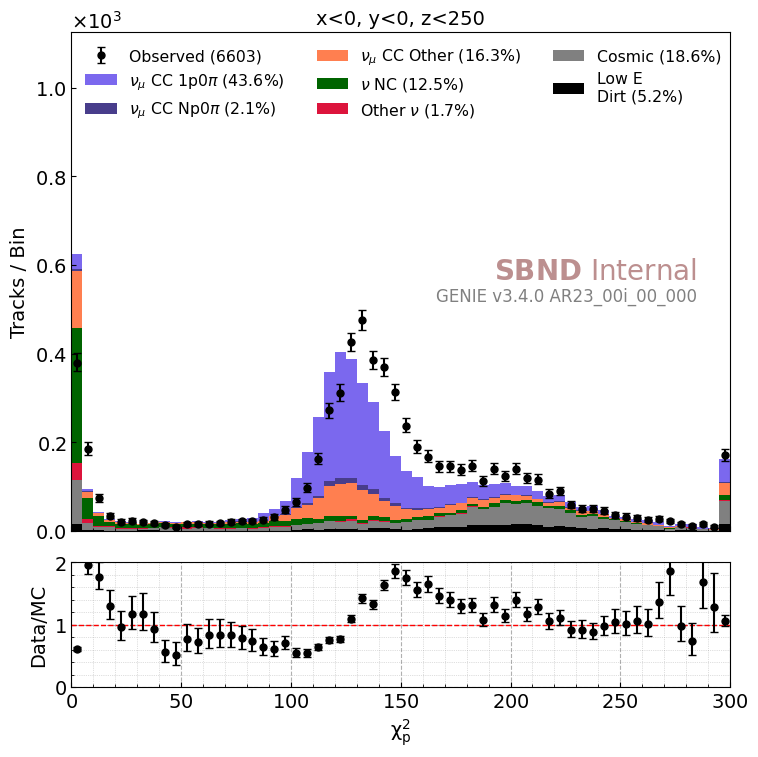

overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


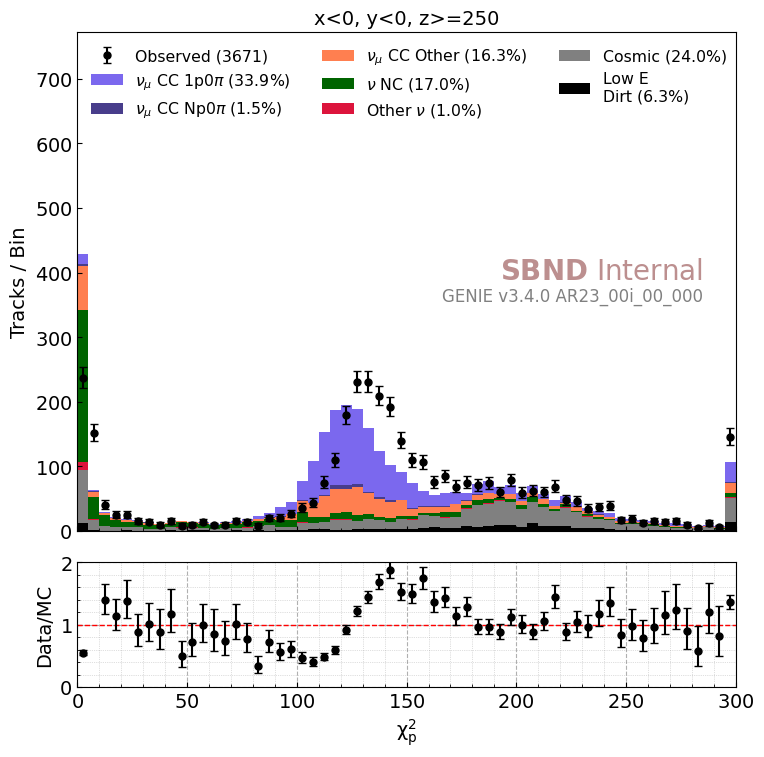

overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


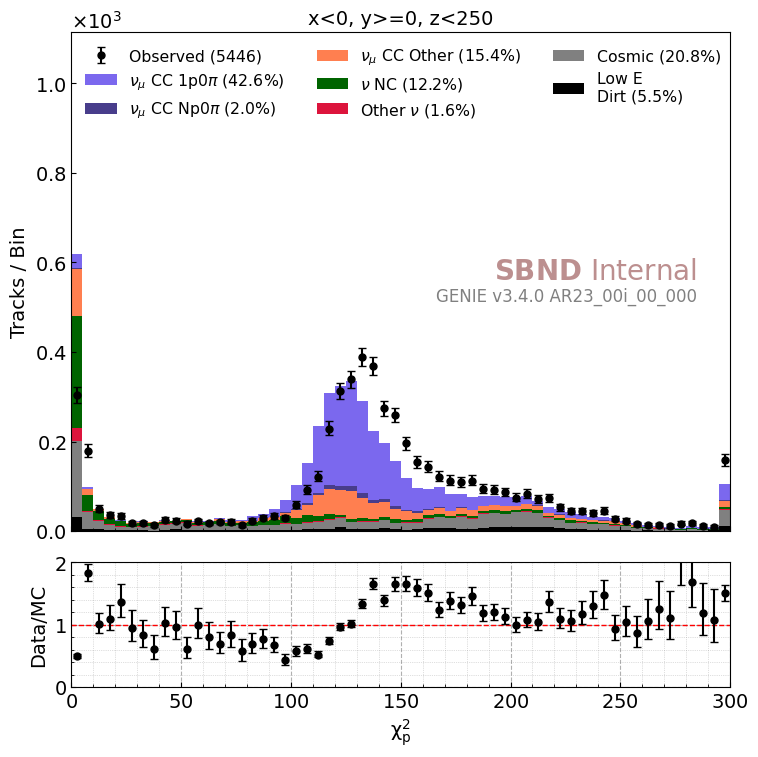

overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


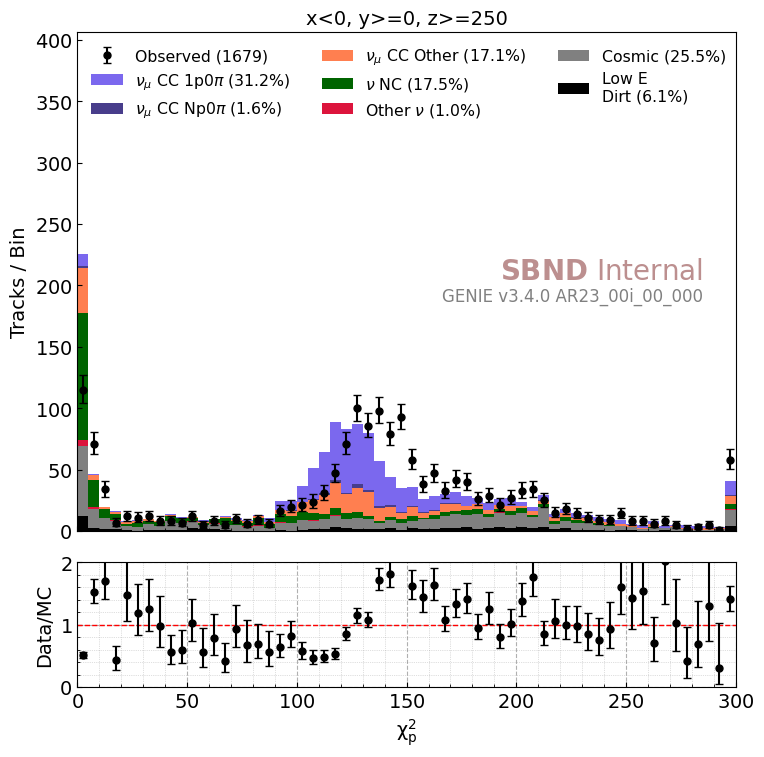

overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


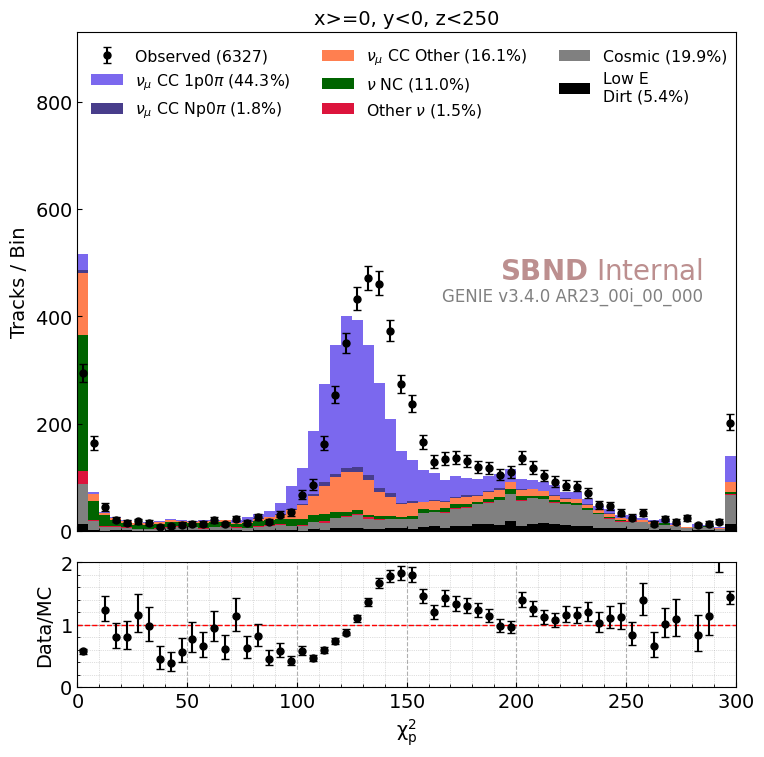

overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


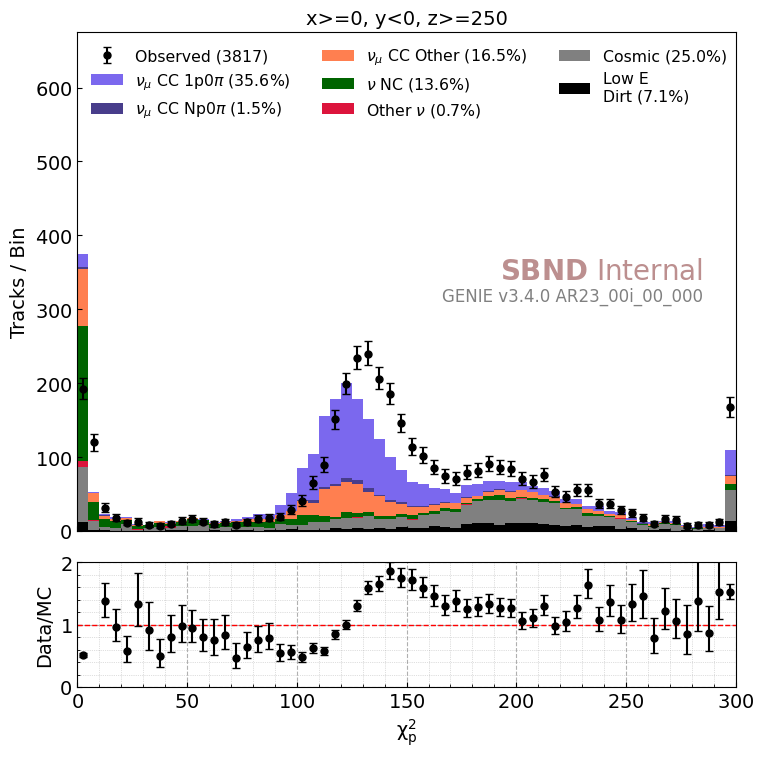

overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


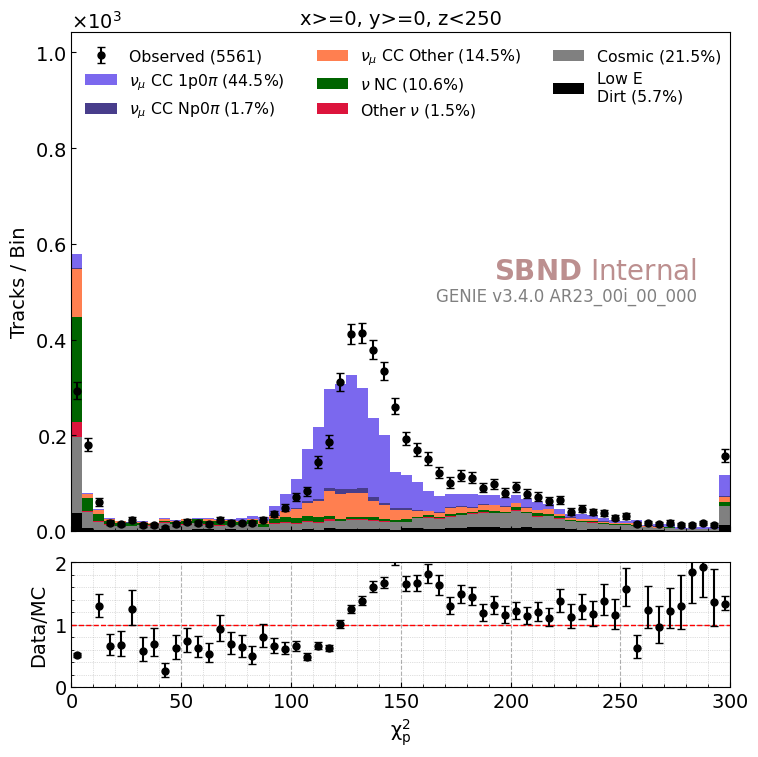

overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


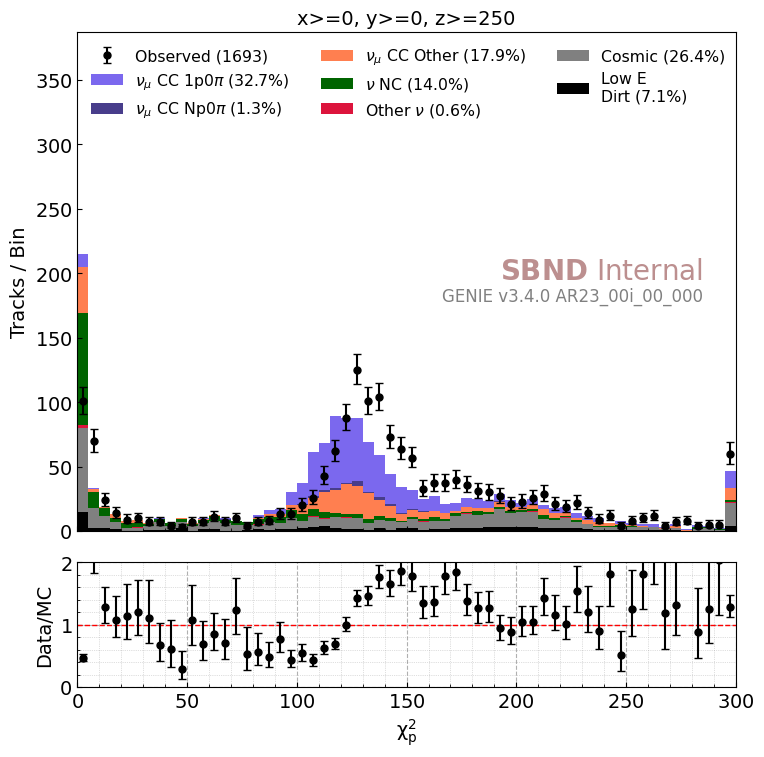

In [54]:
plot_type = "topology"

var_config = VariableConfig.trk1_chi2_proton()

# for i in range(8):
#     save_name = save_fig_dir + "/2prong-{}_{}-octant-{}.png".format(var_config.var_save_name, plot_type, i)
#     plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
#     ret_hist = overlay_hists(plot_type,
#                             mc_df=mc_evt_df_octants[i],
#                             data_df=data_evt_df_octants[i],
#                             intime_df=intime_evt_df_octants[i],
#                             dirt_df=dirt_evt_df_octants[i],
#                             syst=get_wiremod_total_frac_cov(var_config),
#                             load_syst_from_summary=False,
#                             syst_decomp=False,
#                             ratio=True,
#                             ax_ylim_ratio=1.8,
#                             var_config=var_config,
#                             plot_labels=plot_labels,
#                             save_fig=save_fig,
                            # save_name=save_name)

for i in range(8):
    save_name = save_fig_dir + "/2prong-{}_{}-octant-{}-gen1.png".format(var_config.var_save_name, plot_type, i)
    plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
    ret_hist = overlay_hists(plot_type,
                            mc_df=mc_evt_df_octants_gen1[i],
                            data_df=data_evt_df_octants_gen1[i],
                            intime_df=intime_evt_df_octants_gen1[i],
                            dirt_df=dirt_evt_df_octants_gen1[i],
                            # syst=get_wiremod_total_frac_cov(var_config),
                            # load_syst_from_summary=False,
                            # syst_decomp=False,
                            ratio=True,
                            ax_ylim_ratio=1.8,
                            var_config=var_config,
                            plot_labels=plot_labels,
                            save_fig=save_fig,
                            save_name=save_name)

overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


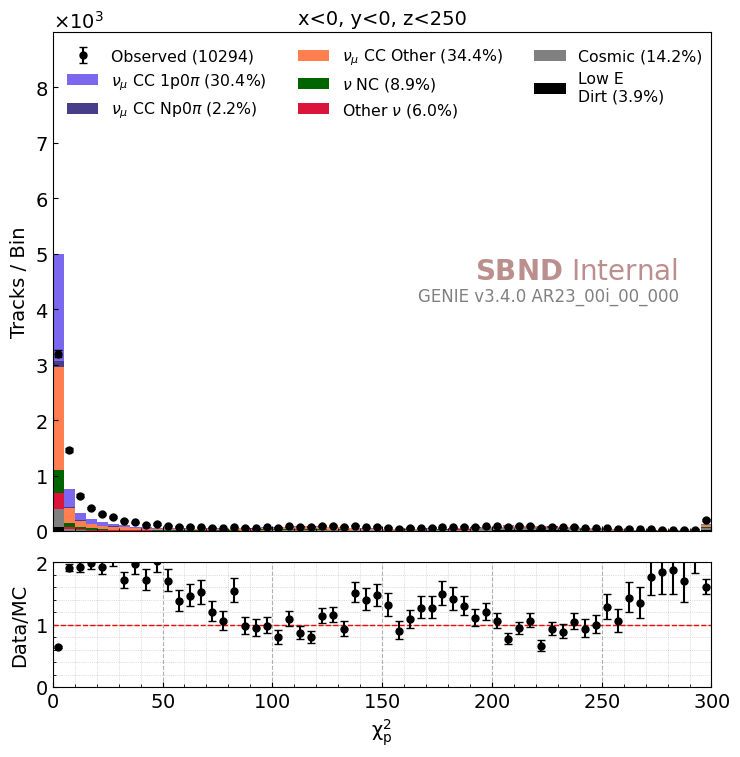

overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


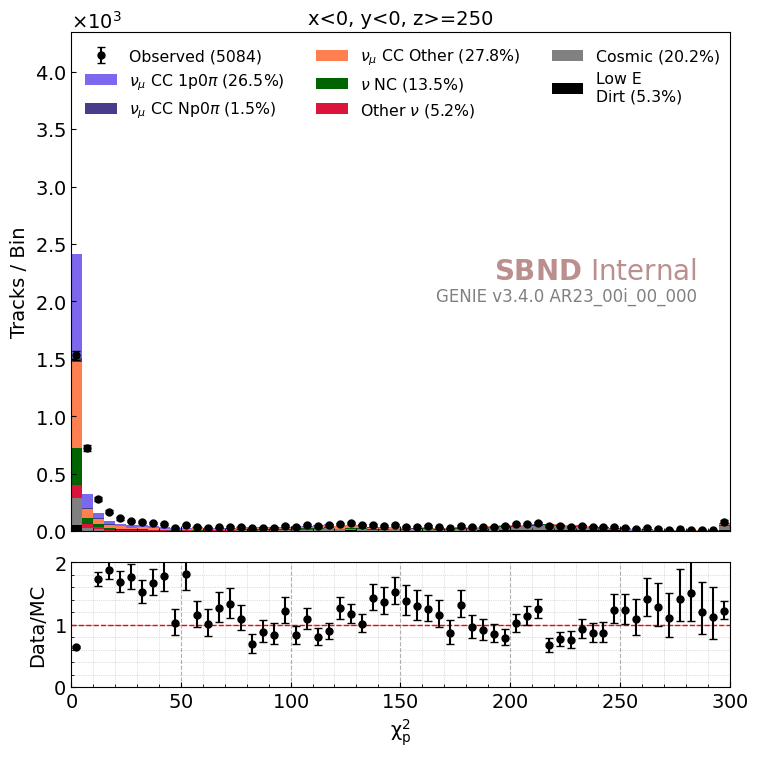

overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


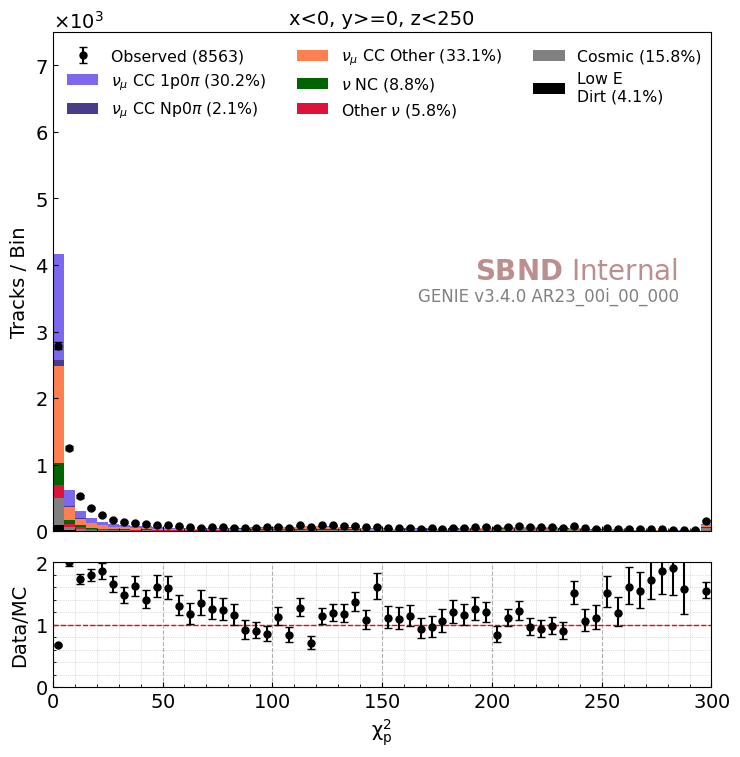

overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


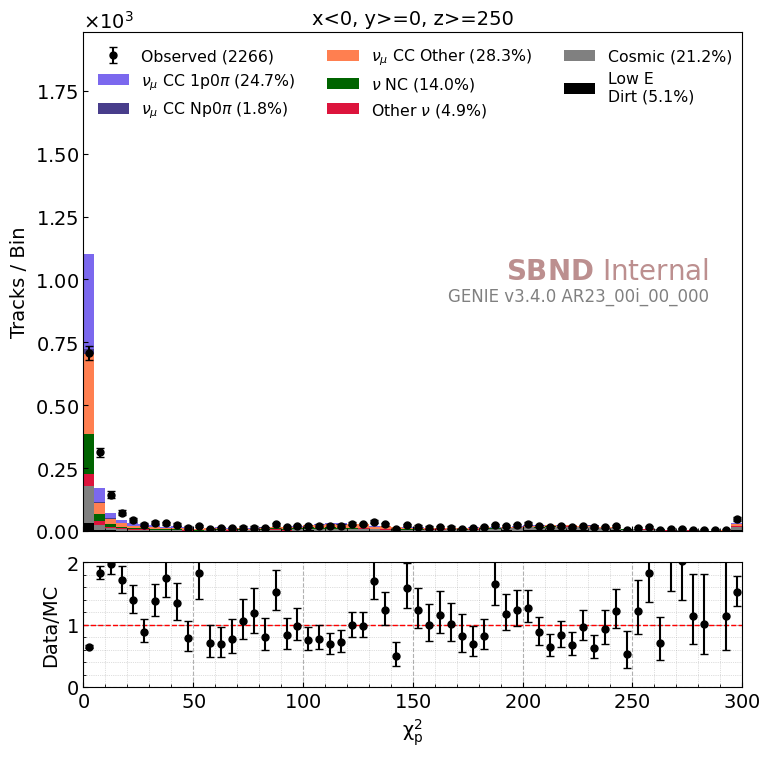

overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


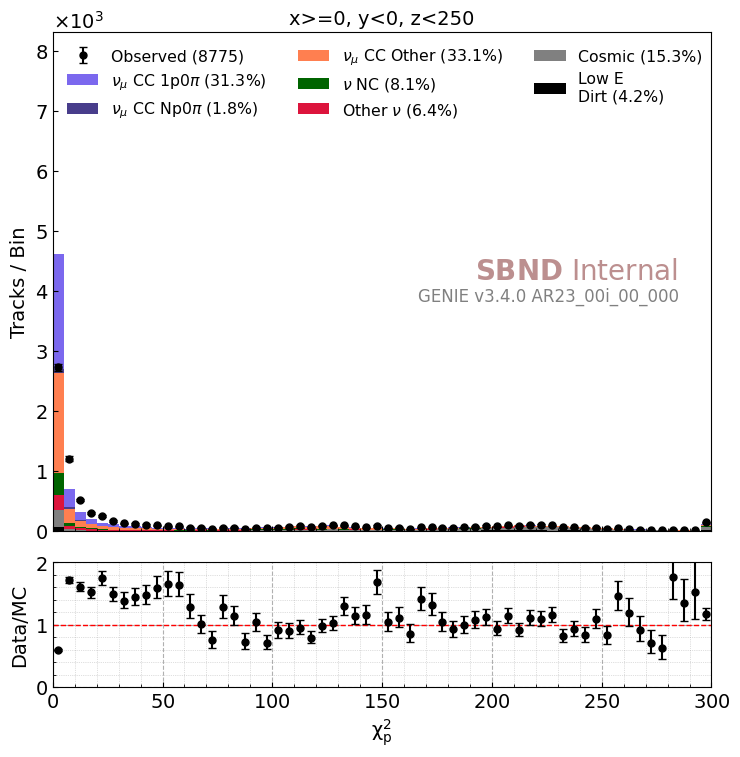

overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


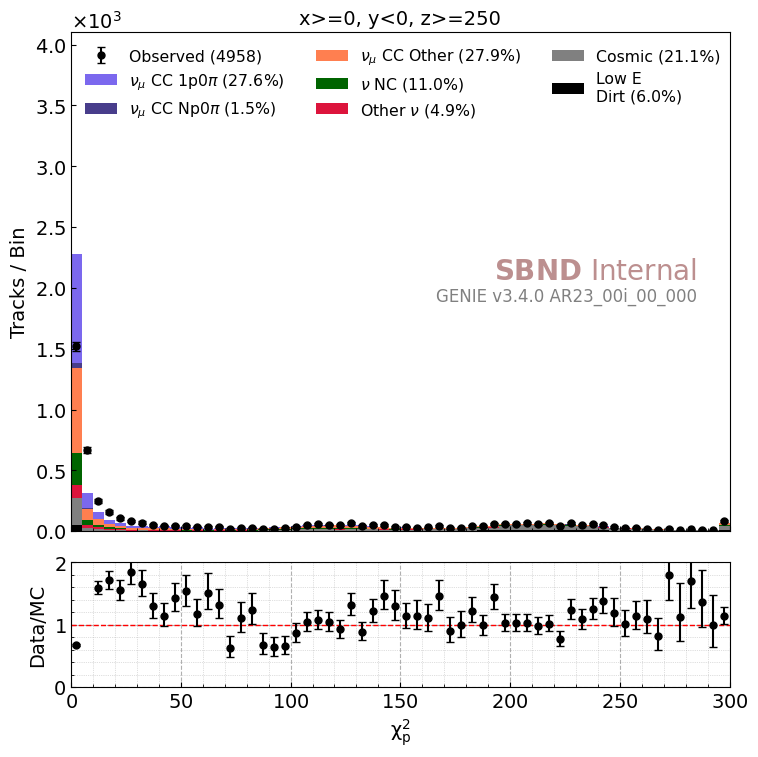

overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


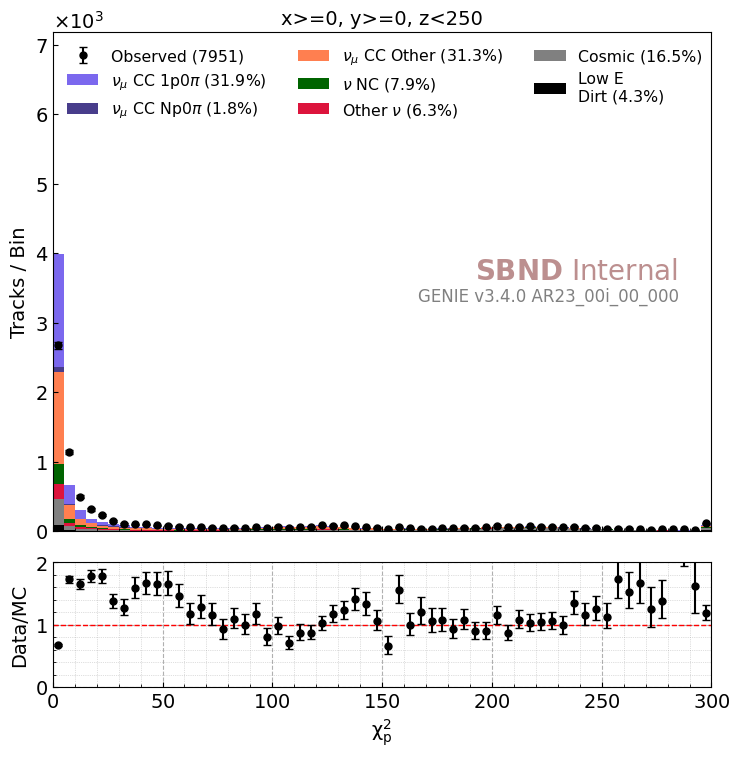

overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


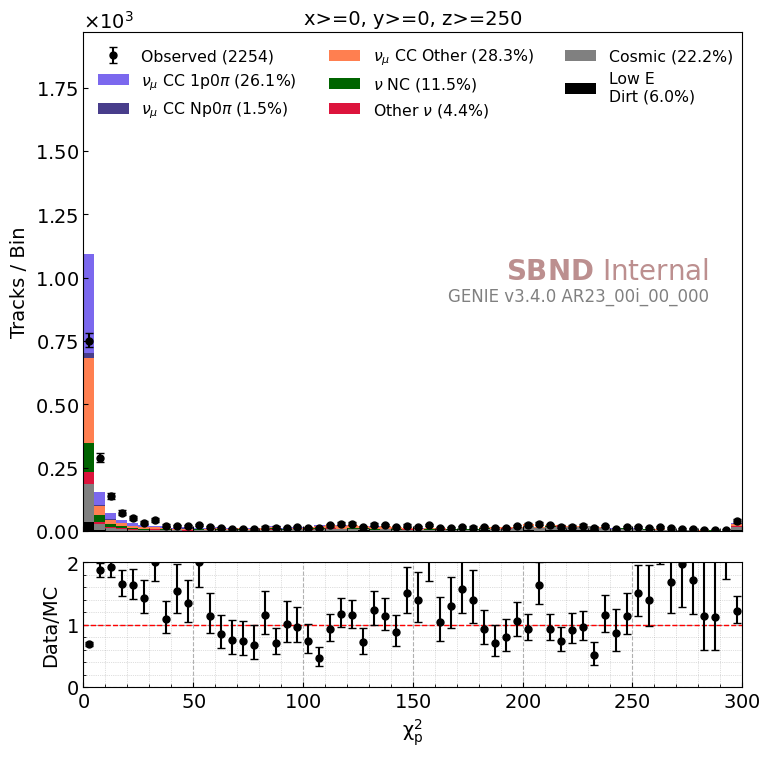

In [12]:
plot_type = "topology"

var_config = VariableConfig.trk2_chi2_proton()

for i in range(8):
    save_name = save_fig_dir + "/2prong-{}_{}-octant-{}.png".format(var_config.var_save_name, plot_type, i)
    plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
    ret_hist = overlay_hists(plot_type,
                            mc_df=mc_evt_df_octants[i],
                            data_df=data_evt_df_octants[i],
                            intime_df=intime_evt_df_octants[i],
                            dirt_df=dirt_evt_df_octants[i],
                            syst=get_wiremod_total_frac_cov(var_config),
                            load_syst_from_summary=False,
                            syst_decomp=False,
                            ratio=True,
                            ax_ylim_ratio=1.8,
                            var_config=var_config,
                            plot_labels=plot_labels,
                            save_fig=save_fig,
                            save_name=save_name)

overlay_hists: could not load category_syst_summary ("Variable 'trk1-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


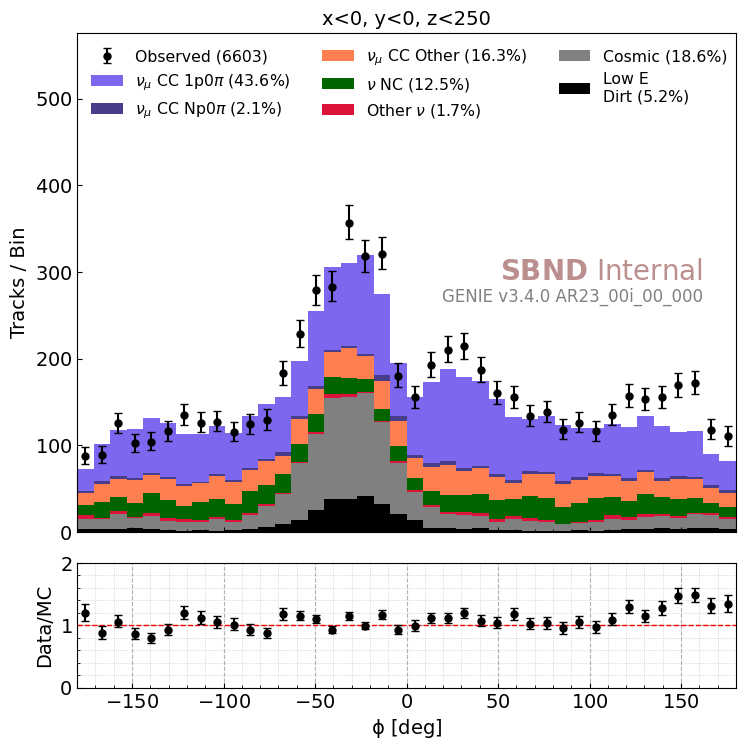

overlay_hists: could not load category_syst_summary ("Variable 'trk1-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


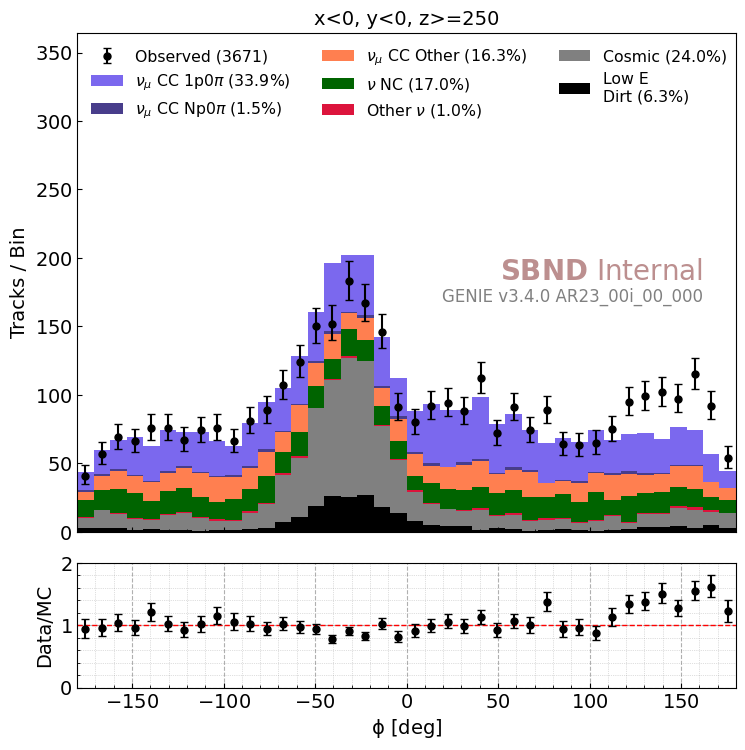

overlay_hists: could not load category_syst_summary ("Variable 'trk1-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


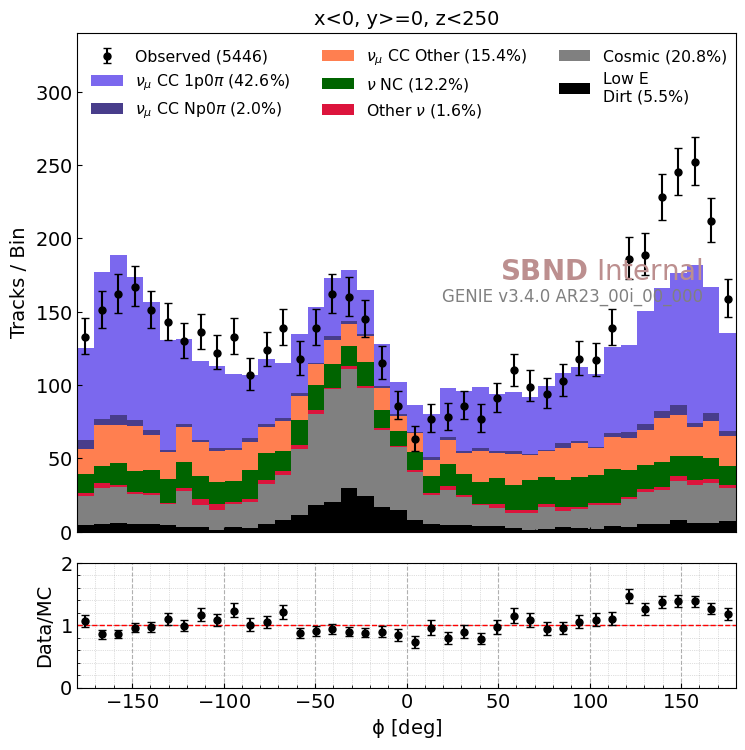

overlay_hists: could not load category_syst_summary ("Variable 'trk1-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


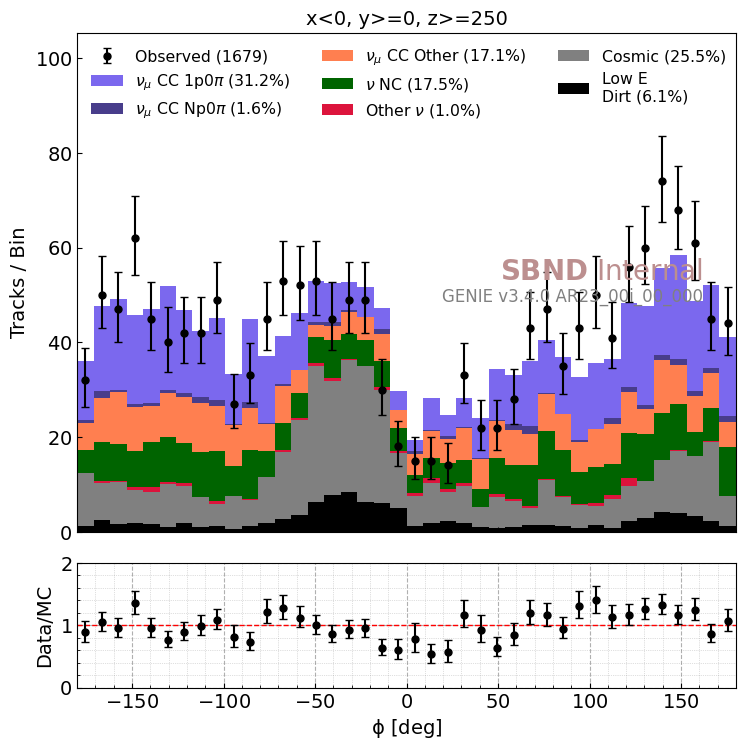

overlay_hists: could not load category_syst_summary ("Variable 'trk1-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


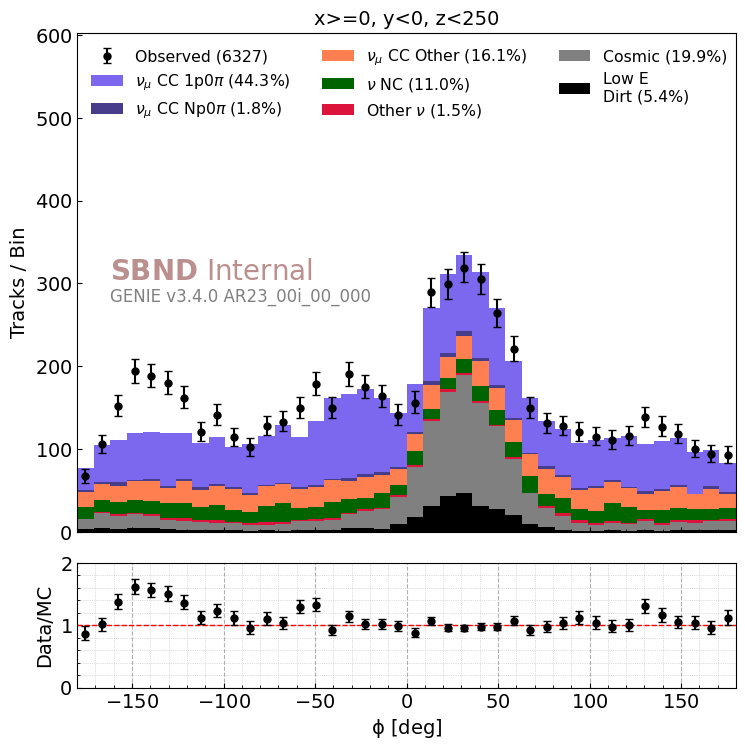

overlay_hists: could not load category_syst_summary ("Variable 'trk1-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


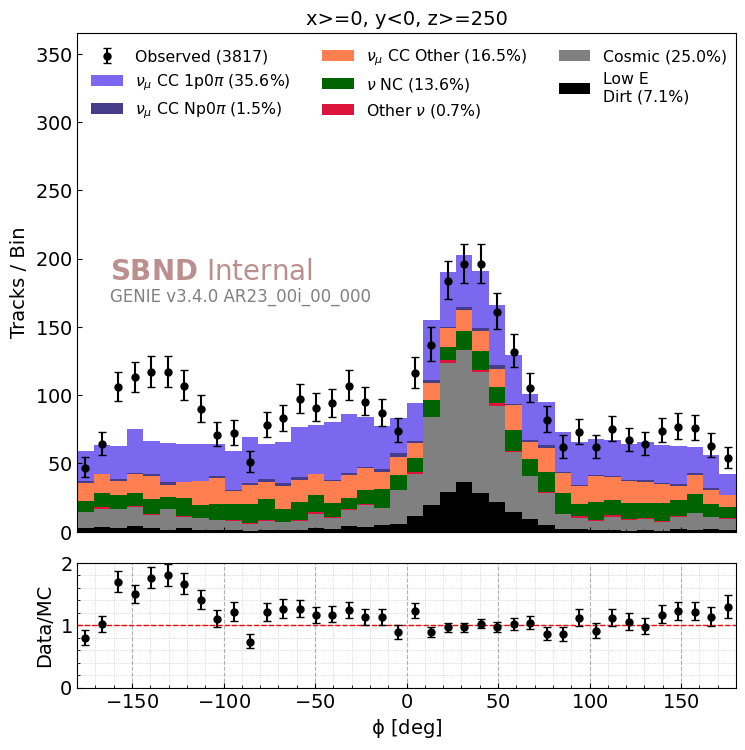

overlay_hists: could not load category_syst_summary ("Variable 'trk1-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


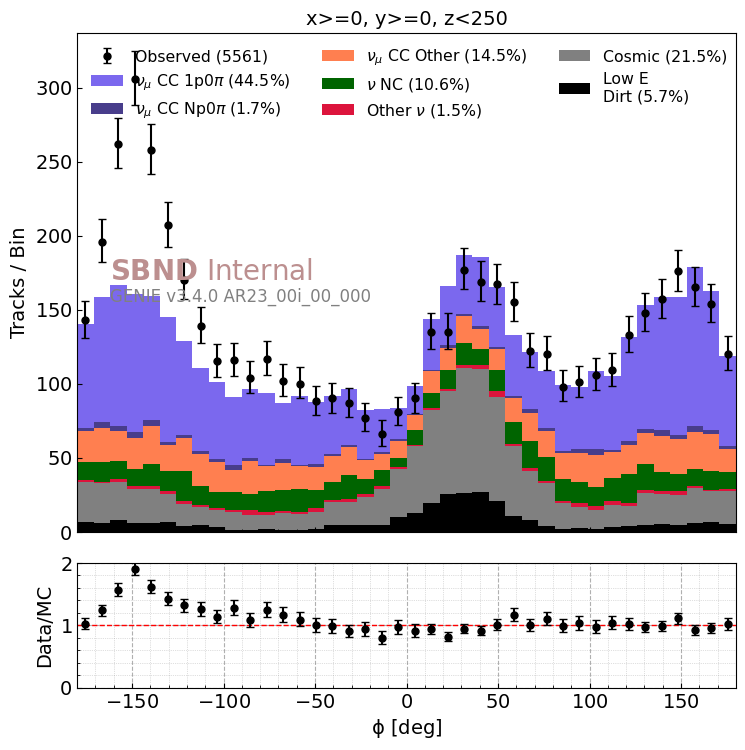

overlay_hists: could not load category_syst_summary ("Variable 'trk1-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


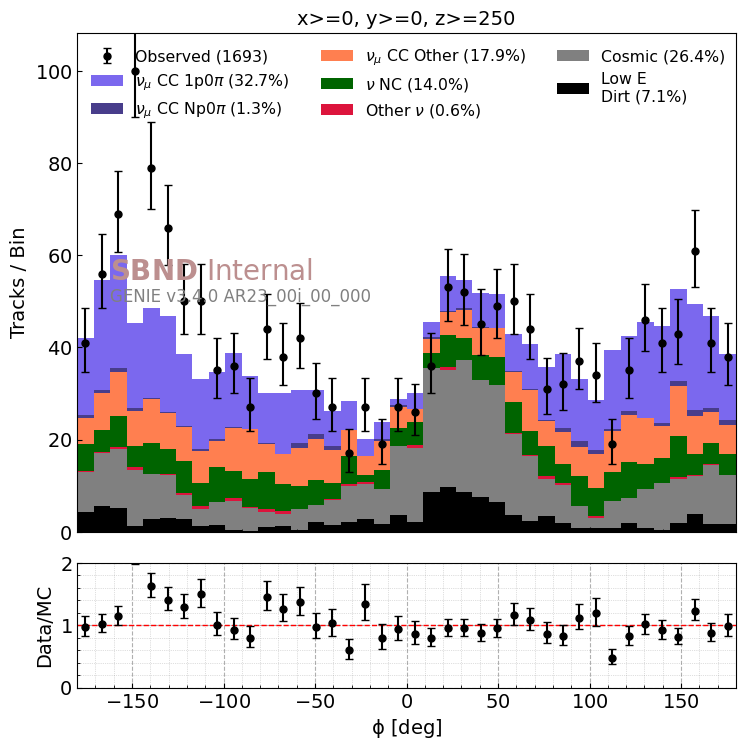

In [55]:
plot_type = "topology"

var_config = VariableConfig.trk1_direction_phi()

# for i in range(8):
#     save_name = save_fig_dir + "/2prong-{}_{}-octant-{}.png".format(var_config.var_save_name, plot_type, i)
#     plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
#     ret_hist = overlay_hists(plot_type,
#                             mc_df=mc_evt_df_octants[i],
#                             data_df=data_evt_df_octants[i],
#                             intime_df=intime_evt_df_octants[i],
#                             dirt_df=dirt_evt_df_octants[i],
#                             syst=get_wiremod_total_frac_cov(var_config),
#                             load_syst_from_summary=False,
#                             syst_decomp=False,
#                             ratio=True,
#                             ax_ylim_ratio=1.8,
#                             var_config=var_config,
#                             plot_labels=plot_labels,
#                             save_fig=save_fig,
#                             save_name=save_name)

for i in range(8):
    save_name = save_fig_dir + "/2prong-{}_{}-octant-{}-gen1.png".format(var_config.var_save_name, plot_type, i)
    plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
    ret_hist = overlay_hists(plot_type,
                            mc_df=mc_evt_df_octants_gen1[i],
                            data_df=data_evt_df_octants_gen1[i],
                            intime_df=intime_evt_df_octants_gen1[i],
                            dirt_df=dirt_evt_df_octants_gen1[i],
                            # syst=get_wiremod_total_frac_cov(var_config),
                            # load_syst_from_summary=False,
                            # syst_decomp=False,
                            ratio=True,
                            ax_ylim_ratio=1.8,
                            var_config=var_config,
                            plot_labels=plot_labels,
                            save_fig=save_fig,
                            save_name=save_name)

overlay_hists: could not load category_syst_summary ("Variable 'trk2-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


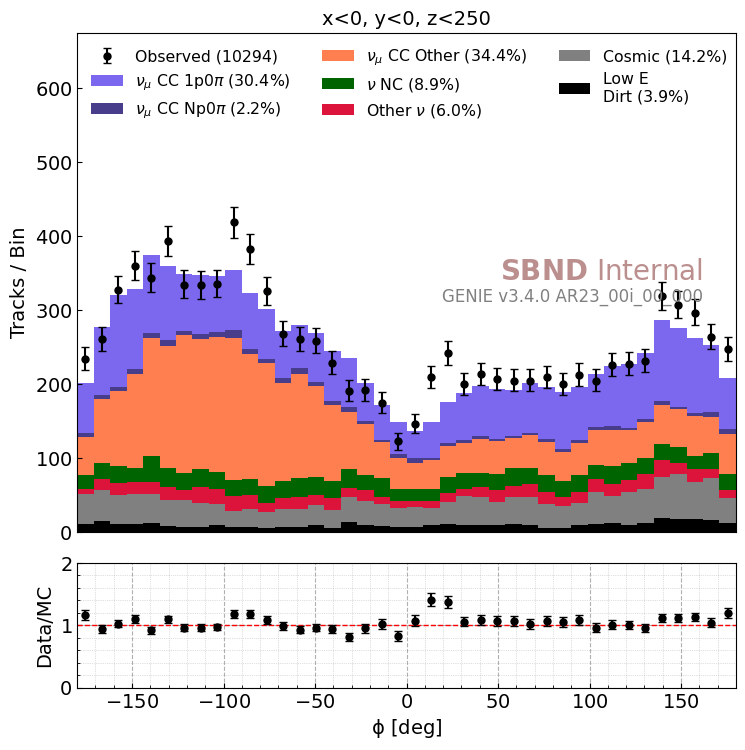

overlay_hists: could not load category_syst_summary ("Variable 'trk2-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


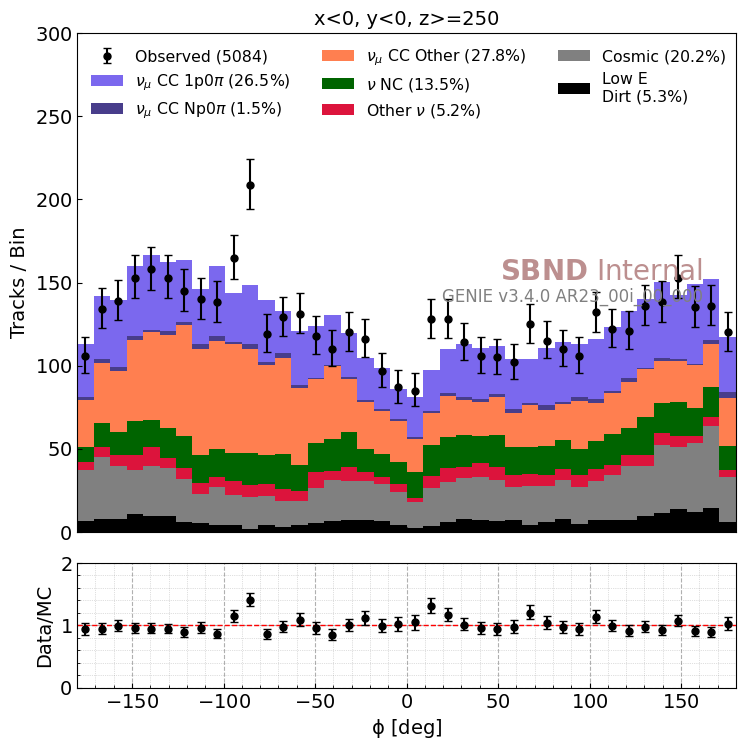

overlay_hists: could not load category_syst_summary ("Variable 'trk2-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


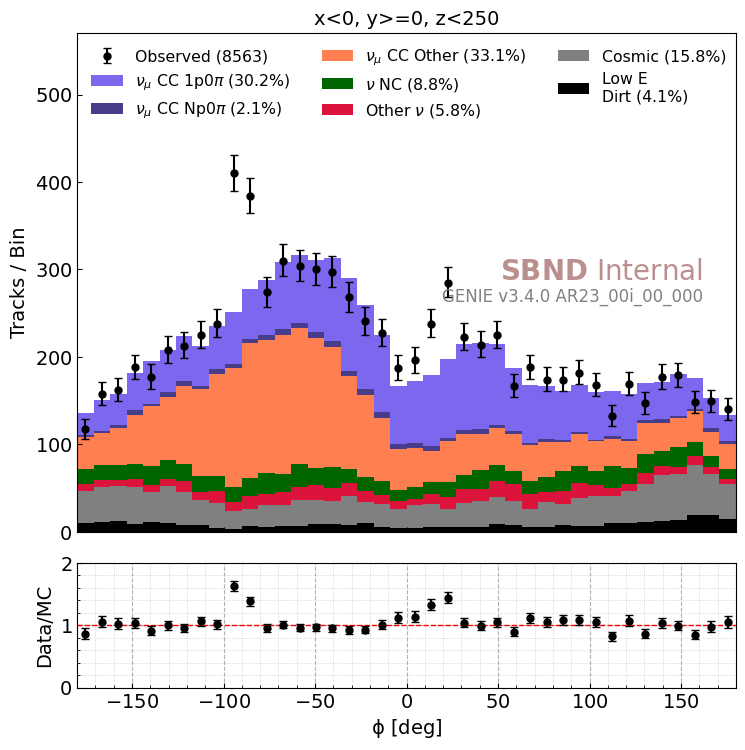

overlay_hists: could not load category_syst_summary ("Variable 'trk2-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


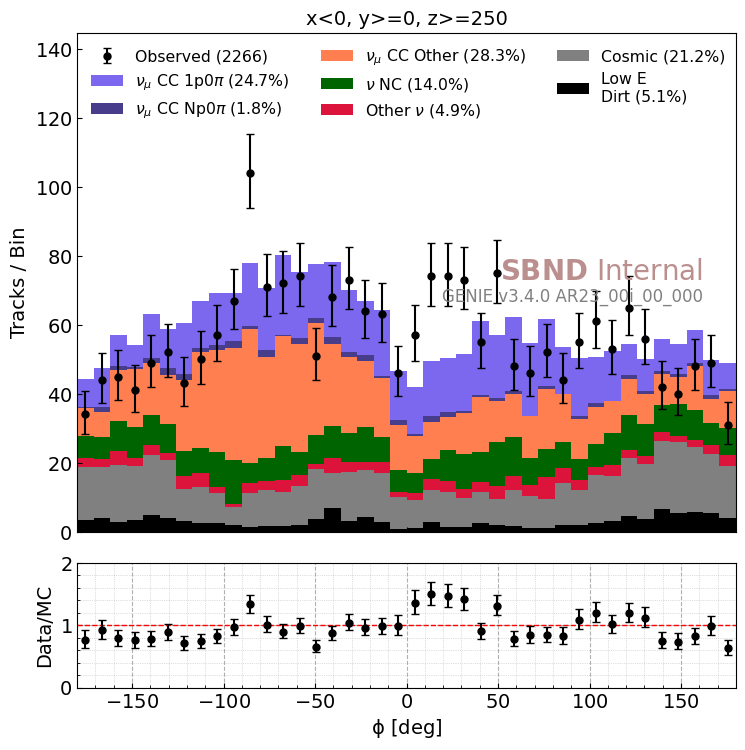

overlay_hists: could not load category_syst_summary ("Variable 'trk2-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


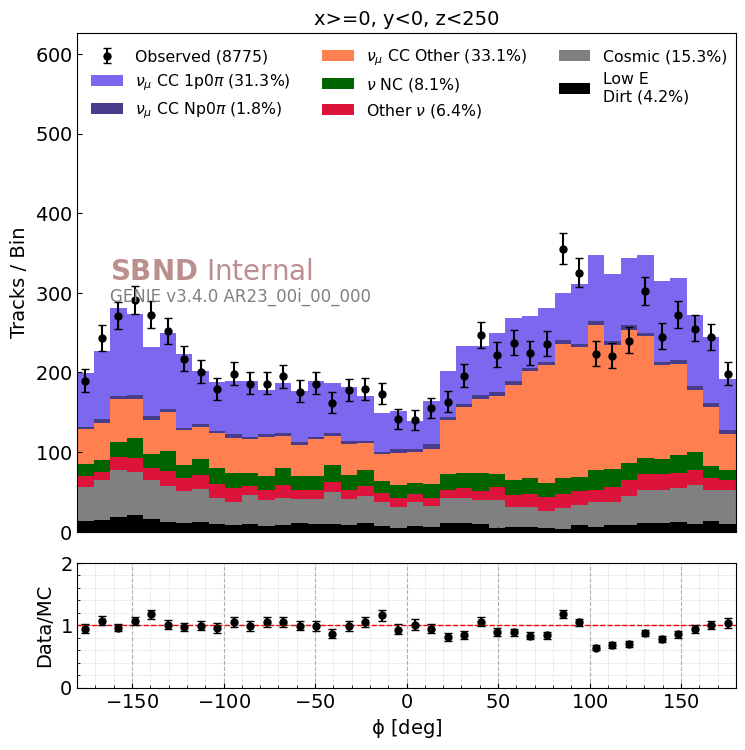

overlay_hists: could not load category_syst_summary ("Variable 'trk2-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


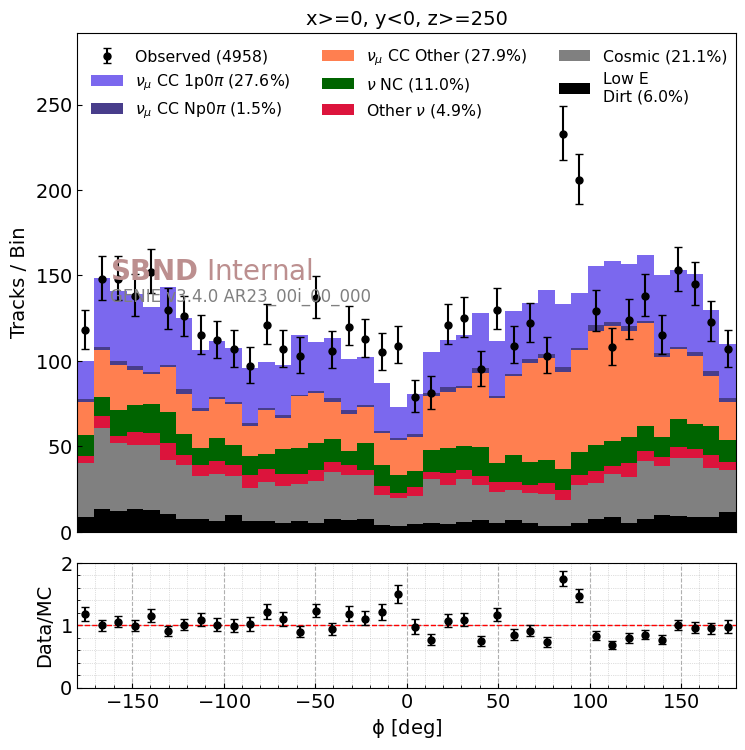

overlay_hists: could not load category_syst_summary ("Variable 'trk2-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


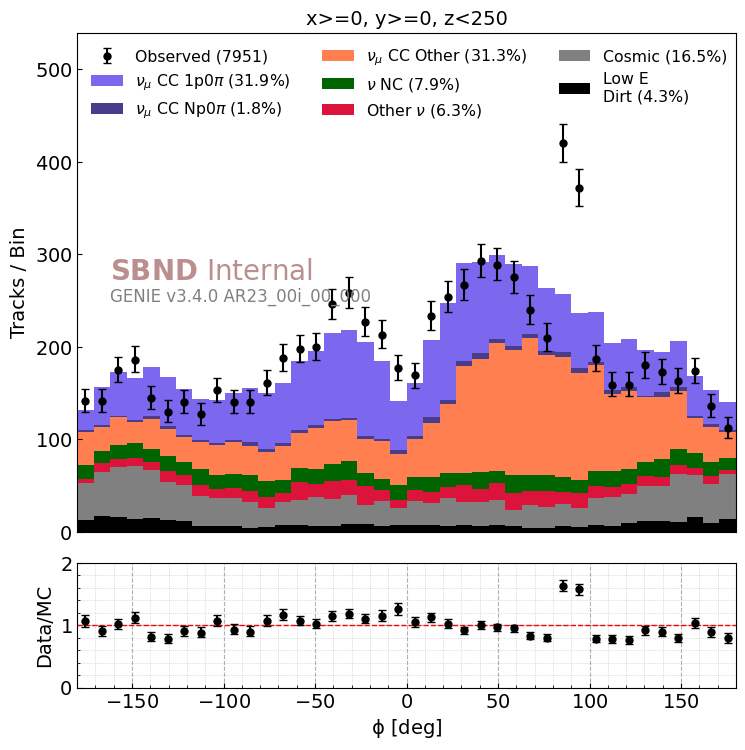

overlay_hists: could not load category_syst_summary ("Variable 'trk2-dir_phi' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided


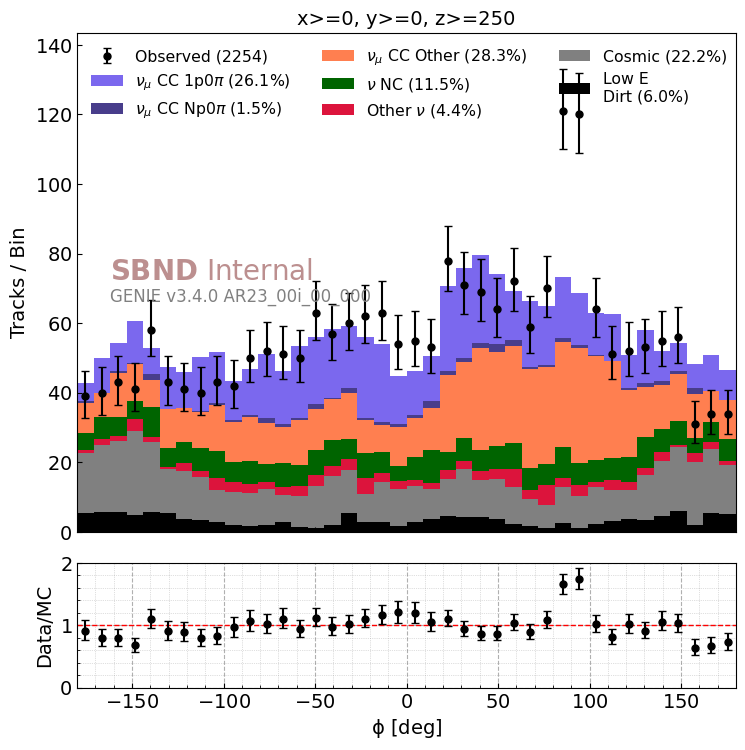

In [23]:
plot_type = "topology"

var_config = VariableConfig.trk2_direction_phi()

for i in range(8):
    save_name = save_fig_dir + "/2prong-{}_{}-octant-{}.png".format(var_config.var_save_name, plot_type, i)
    plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
    ret_hist = overlay_hists(plot_type,
                            mc_df=mc_evt_df_octants[i],
                            data_df=data_evt_df_octants[i],
                            intime_df=intime_evt_df_octants[i],
                            dirt_df=dirt_evt_df_octants[i],
                            syst=get_wiremod_total_frac_cov(var_config),
                            load_syst_from_summary=False,
                            syst_decomp=False,
                            ratio=True,
                            ax_ylim_ratio=1.8,
                            var_config=var_config,
                            plot_labels=plot_labels,
                            save_fig=save_fig,
                            save_name=save_name)

In [25]:
save_fig_dir

'/exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602'